# Optical Routing — Deep Dive

This page covers advanced optical routing features.
For a quick intro see [Routing Overview](overview.py).

| Topic | API |
|---|---|
| Waypoints | `route_bundle(..., waypoints=[...])` |
| Entry / exit stubs | `route_bundle(..., starts=..., ends=...)` |
| Path-length matching | `route_bundle(..., constraints=[kf.PathLengthMatch(...)], route_name=...)` |
| Loopback — inside variant | `route_loopback(..., inside=True)` |
| Direct backbone placement | `place_manhattan(c, p1, p2, pts, ...)` |

## Setup

All factories and ports must share the same `KCLayout` instance — here the global `kf.kcl`.

In [1]:
from functools import partial

import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

wg_enc = kf.kcl.get_enclosure(
    kf.LayerEnclosure(name="WGSTD_OPT", sections=[(L.WGCLAD, 0, 2_000)])
)

# Euler bend — width and radius in µm
bend90 = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
    width=0.5,
    radius=10,
    layer=L.WG,
    enclosure=wg_enc,
    angle=90,
)

# Straight factory — width and length in DBU
straight_factory = partial(
    kf.factories.straight.straight_dbu_factory(kcl=kf.kcl),
    layer=L.WG,
    enclosure=wg_enc,
)

WG_WIDTH = kf.kcl.to_dbu(0.5)  # 500 DBU

# Effective routing radius of the euler bend (larger than the nominal 10 µm)
bend_radius = kf.routing.optical.get_radius(bend90)

## 1 · Waypoints — guiding routes through fixed points

A `waypoints` value forces all routes to converge at a specific position and direction
before continuing to their end ports.

- Pass a `kdb.Trans` to specify a single convergence point with a direction.
- Pass a `list[kdb.Point]` to define a backbone corridor (direction inferred from
  the first two points).

Below, three East–West routes are forced to detour upward through a corridor at
y = 80 µm (simulating a gap above an obstacle) before descending to their
West-facing end ports.

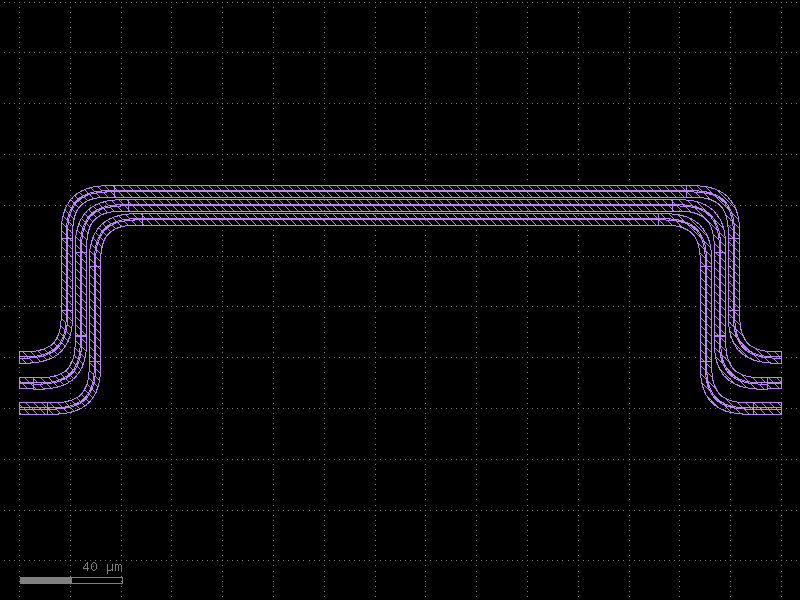

In [2]:
c_wp = kf.KCell("opt_waypoints")

n = 3
wp_starts = [
    kf.Port(
        name=f"in_{i}",
        # angle=0 → East-facing
        trans=kf.kdb.Trans(0, False, 0, kf.kcl.to_dbu(i * 10)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(n)
]
wp_ends = [
    kf.Port(
        name=f"out_{i}",
        # angle=2 → West-facing (opposite to East, so routes connect left-to-right)
        trans=kf.kdb.Trans(2, False, kf.kcl.to_dbu(300), kf.kcl.to_dbu(i * 10)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(n)
]

# Waypoint: at (150 µm, 80 µm) heading East.
# All routes must pass through this corridor before reaching their end ports.
kf.routing.optical.route_bundle(
    c_wp,
    wp_starts,
    wp_ends,
    separation=kf.kcl.to_dbu(5),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    waypoints=kf.kdb.Trans(0, False, kf.kcl.to_dbu(150), kf.kcl.to_dbu(80)),
)
c_wp

## 2 · Entry and exit stubs — `starts` and `ends`

`starts` / `ends` control how far each route must travel straight before the router
takes over.  Supplying a scalar applies the same stub length to all routes; a list
gives per-route control (DBU).

Stubs are useful when you need clearance from a device before bending, or when routing
out of a dense array.

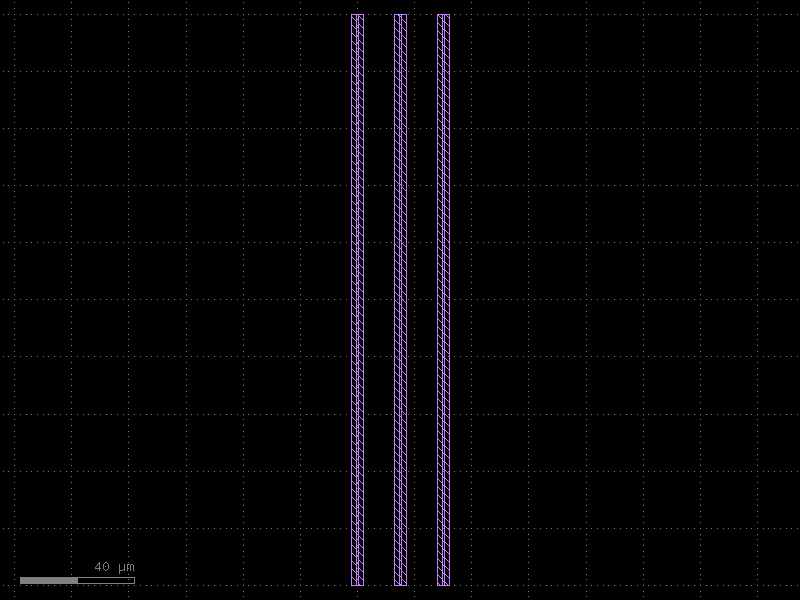

In [3]:
c_stubs = kf.KCell("opt_stubs")

stub_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 15), 0),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
stub_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(i * 15), kf.kcl.to_dbu(200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]

# Each start port extends 20 µm straight before the bend, each end 10 µm.
kf.routing.optical.route_bundle(
    c_stubs,
    stub_starts,
    stub_ends,
    separation=kf.kcl.to_dbu(5),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    starts=kf.kcl.to_dbu(20),  # scalar → all routes get the same start stub
    ends=kf.kcl.to_dbu(10),
)
c_stubs

## 3 · Path-length matching

When routes travel different distances (e.g. fan-outs from an array where starts are
staggered), `kf.PathLengthMatch` inserts small "squiggle" loops on the shorter
routes so that all waveguide lengths become equal.  It runs as a *constraint* on
`route_bundle`: backbones are computed first, then the constraint walks the routers
of every bundle whose `route_name` it matches and rewrites the shorter ones.

**`PathLengthMatch` fields:**

| Field | Type | Meaning |
|---|---|---|
| `route_names` | `list[str]` | `route_name`s of the bundles to equalise |
| `element` | `int` | Which backbone segment to insert the loop into. `-1` = last segment. |
| `loop_side` | `int` | `-1` = loop on left, `0` = centered, `1` = loop on right |
| `loops` | `int` | Number of loop repetitions |
| `loop_position` | `int` | `-1` = near start of segment, `0` = center, `1` = near end |
| `length` | `int \| None` | Target path length in DBU. `None` = match the longest router. |
| `tolerance` | `int` | Maximum allowed length spread (DBU) after enforcement |

> **Note**: All routes must be routed first (the constraint runs after the
> backbones are generated), so routes need enough room for the inserted loops —
> increase `separation` or stagger ports as needed.

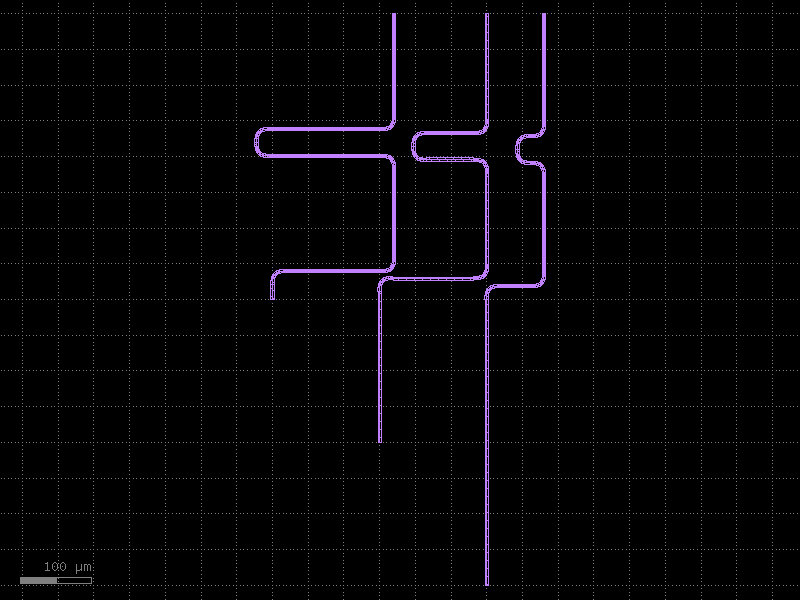

In [4]:
c_plm = kf.KCell("opt_path_length_match")

# Stagger start ports so that each route naturally has a different path length.
# Routes need sufficient horizontal separation (≥ 2× bend_radius) so the inserted
# loops don't overlap adjacent waveguides.
plm_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 150), kf.kcl.to_dbu(-i * 200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
plm_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(x), kf.kcl.to_dbu(400)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i, x in enumerate([170, 300, 380])
]

kf.routing.optical.route_bundle(
    c_plm,
    plm_starts,
    plm_ends,
    separation=kf.kcl.to_dbu(10),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    constraints=[
        kf.PathLengthMatch(
            route_names=["plm_demo"],
            element=-1,        # insert loop in the last backbone segment
            loop_side=-1,      # loops on the left side
            loops=1,
            loop_position=0,   # centered in the segment
        )
    ],
    route_name="plm_demo",
)
c_plm

## 4 · Loopback — inside variant

`route_loopback` supports two topologies controlled by `inside`:

```
inside=False (default)       inside=True
╭----╮  ╭----╮                  ╭---╮  ╭---╮
|    |  |    |                  |   |  |   |
| ----- ----- |              ----- |  | -----
| p1       p2 |              p1   |    |   p2
╰─────────────╯                   ╰────╯
```

`inside=False` (default) creates an outer U-turn that travels away from the array.
`inside=True` creates an inner U-turn that folds back between adjacent ports — useful
for compact test structures where the loop must fit within the device footprint.

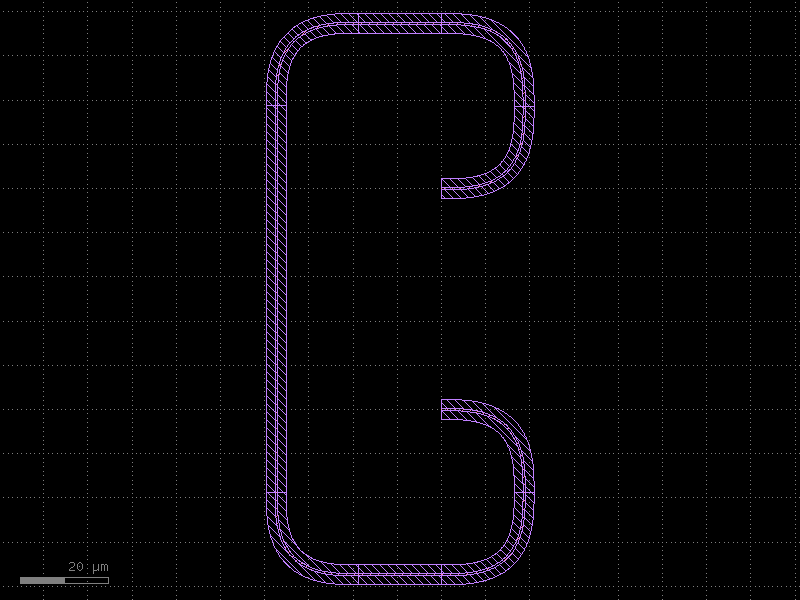

In [5]:
c_lb_inside = kf.KCell("opt_loopback_inside")

lb_p1 = kf.Port(
    name="p1",
    trans=kf.kdb.Trans(0, False, 0, 0),
    width=WG_WIDTH,
    layer_info=L.WG,
)
lb_p2 = kf.Port(
    name="p2",
    trans=kf.kdb.Trans(0, False, 0, kf.kcl.to_dbu(50)),
    width=WG_WIDTH,
    layer_info=L.WG,
)

backbone_inside = kf.routing.optical.route_loopback(
    lb_p1,
    lb_p2,
    bend90_radius=bend_radius,
    d_loop=bend_radius * 2,
    inside=True,
)

kf.routing.optical.place_manhattan(
    c_lb_inside,
    lb_p1,
    lb_p2,
    backbone_inside,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_lb_inside

## 5 · Direct backbone placement with `place_manhattan`

`route_bundle` is the high-level router.  For full control you can build the backbone
yourself (a list of `kdb.Point`) and call `place_manhattan` directly to materialise
waveguide segments and bend cells along it.

This is the same function that `route_bundle` calls internally, exposed so that custom
routing algorithms can drive the placer.

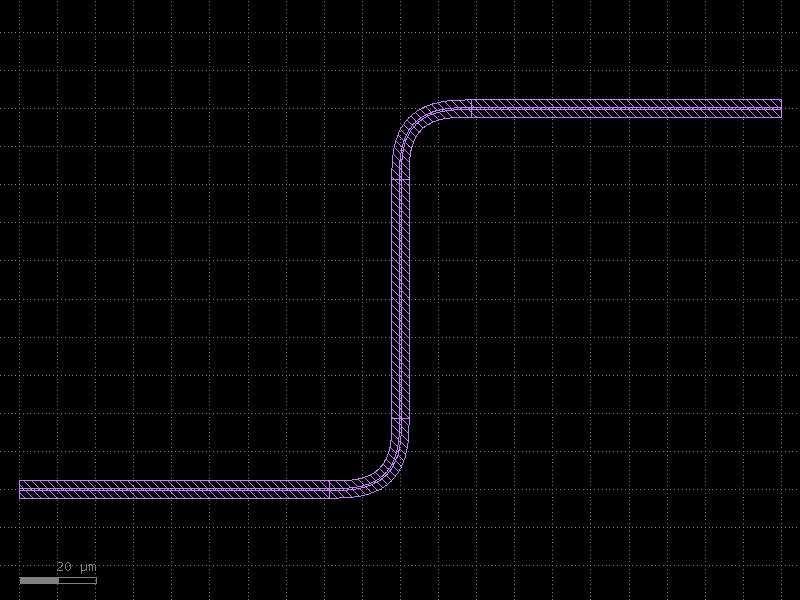

In [6]:
c_pm = kf.KCell("opt_place_manhattan_direct")

pm_p1 = kf.Port(
    name="o1",
    trans=kf.kdb.Trans(0, False, 0, 0),
    width=WG_WIDTH,
    layer_info=L.WG,
)
pm_p2 = kf.Port(
    name="o2",
    trans=kf.kdb.Trans(2, False, kf.kcl.to_dbu(200), kf.kcl.to_dbu(100)),
    width=WG_WIDTH,
    layer_info=L.WG,
)

# Hand-crafted Manhattan backbone: go East, then North, then West.
# Points are the *corners* of the route including the start and end positions.
custom_backbone = [
    kf.kdb.Point(0, 0),
    kf.kdb.Point(kf.kcl.to_dbu(100), 0),
    kf.kdb.Point(kf.kcl.to_dbu(100), kf.kcl.to_dbu(100)),
    kf.kdb.Point(kf.kcl.to_dbu(200), kf.kcl.to_dbu(100)),
]

kf.routing.optical.place_manhattan(
    c_pm,
    pm_p1,
    pm_p2,
    custom_backbone,
    straight_factory=straight_factory,
    bend90_cell=bend90,
)
c_pm

## Summary

| Need | Parameter / function |
|---|---|
| Route through a fixed corridor | `waypoints=[kdb.Point(...), ...]` |
| Guarantee minimum straight before bend | `starts=dbu_length` (scalar or per-route list) |
| Equalise optical path lengths | `constraints=[kf.PathLengthMatch(route_names=["b"], element=-1, loop_side=-1, loops=1, loop_position=0)]`, `route_name="b"` |
| Compact inner U-turn | `route_loopback(..., inside=True)` |
| Custom routing algorithm output | `place_manhattan(c, p1, p2, pts, straight_factory=..., bend90_cell=...)` |

All coordinates passed to `KCell`-based APIs are in **DBU** (1 nm = 1 DBU with default
`dbu=0.001`).  Convert with `kf.kcl.to_dbu(x_µm)`.

## See Also

| Topic | Where |
|-------|-------|
| Routing overview (optical + electrical entry point) | [Routing: Overview](overview.py) |
| Bundle routing details: sort, sbend, bbox modes | [Routing: Bundle](bundle.py) |
| Equal path-length loops | [Routing: Path Length](path_length.py) |
| Low-level backbone + Steps API | [Routing: Manhattan](manhattan.py) |
| All-angle (non-manhattan) routing | [Routing: All-Angle](all_angle.py) |
| Euler bend effective radius | [Components: Euler Bends](../components/cells/factories/euler.py) |
| Port construction and connection | [Core Concepts: Ports](../concepts/ports.py) |